# 03. Exploratory Data Analysis
Phân tích khám phá ban đầu: phân phối giá, brand, category, rating, sales patterns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [2]:
df = pd.read_csv('../data/processed/combined_tiki_data.csv')
df['discount_pct'] = ((df['original_price'] - df['price']) / df['original_price'] * 100).round(2)
df['revenue_estimate'] = df['price'] * df['quantity_sold']
print(f"Dataset: {df.shape}")

Dataset: (41576, 21)


## Price Distribution

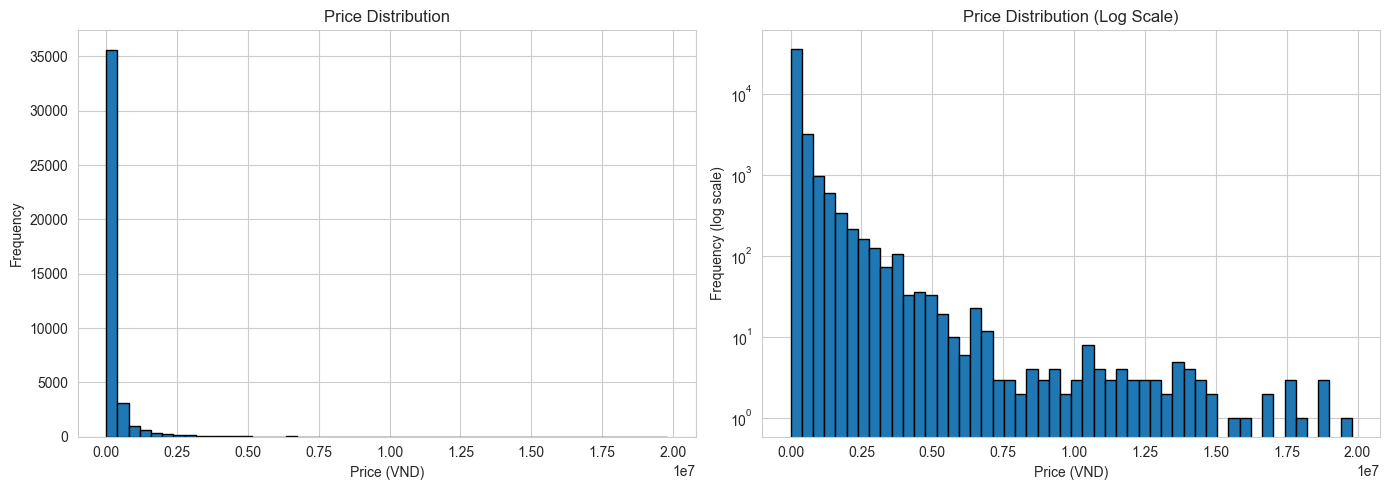

Price statistics:
count    4.157600e+04
mean     2.723589e+05
std      7.630026e+05
min      0.000000e+00
25%      3.900000e+04
50%      8.500000e+04
75%      2.100000e+05
max      1.980000e+07
Name: price, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['price'], bins=50, edgecolor='black')
axes[0].set_xlabel('Price (VND)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Price Distribution')

axes[1].hist(df['price'], bins=50, edgecolor='black', log=True)
axes[1].set_xlabel('Price (VND)')
axes[1].set_ylabel('Frequency (log scale)')
axes[1].set_title('Price Distribution (Log Scale)')

plt.tight_layout()
plt.show()

print(f"Price statistics:")
print(df['price'].describe())

## Category Analysis

In [4]:
category_stats = df.groupby('category').agg({
    'id': 'count',
    'price': 'mean',
    'quantity_sold': 'sum',
    'rating_average': 'mean',
    'review_count': 'sum',
    'revenue_estimate': 'sum'
}).round(2)
category_stats.columns = ['product_count', 'avg_price', 'total_sold', 'avg_rating', 'total_reviews', 'total_revenue']
category_stats = category_stats.sort_values('total_revenue', ascending=False)
print(category_stats)

                     product_count  avg_price  total_sold  avg_rating  \
category                                                                
backpacks_suitcases           5359  497302.11      113250        1.50   
men_shoes                     5744  372352.04       95197        1.62   
fashion_accessories          16005   81942.21      253418        1.30   
women_shoes                   5917  284224.60      131189        1.64   
men_bags                      4227  581026.56      105548        1.25   
women_bags                    4324  247576.15       40492        1.01   

                     total_reviews  total_revenue  
category                                           
backpacks_suitcases          21081    28992857627  
men_shoes                    22016    15447480294  
fashion_accessories          38574    14038799131  
women_shoes                  23073    12862336064  
men_bags                     16315    12054289756  
women_bags                    8329     3001945580  

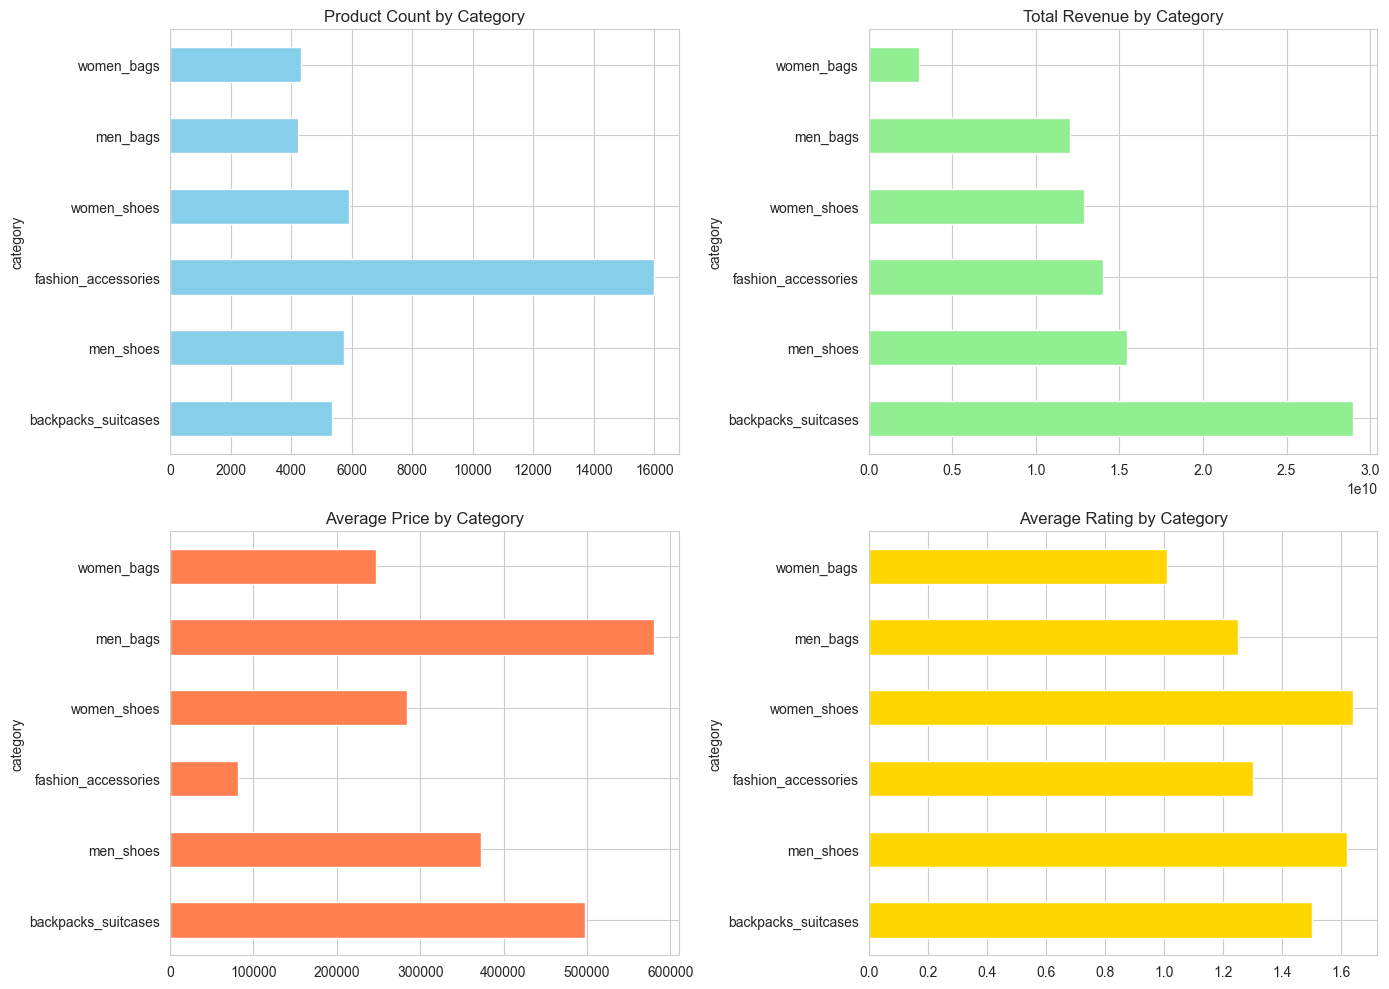

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

category_stats['product_count'].plot(kind='barh', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Product Count by Category')

category_stats['total_revenue'].plot(kind='barh', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Total Revenue by Category')

category_stats['avg_price'].plot(kind='barh', ax=axes[1,0], color='coral')
axes[1,0].set_title('Average Price by Category')

category_stats['avg_rating'].plot(kind='barh', ax=axes[1,1], color='gold')
axes[1,1].set_title('Average Rating by Category')

plt.tight_layout()
plt.show()

## Brand Analysis

In [6]:
print(f"Total unique brands: {df['brand'].nunique()}")
print(f"\nTop 20 brands by product count:")
top_brands = df['brand'].value_counts().head(20)
print(top_brands)

oem_count = df[df['brand'] == 'OEM']['id'].count()
print(f"\nOEM products: {oem_count} ({oem_count/len(df)*100:.1f}%)")

Total unique brands: 824

Top 20 brands by product count:
brand
OEM                              30673
Song An Eco                        509
\tOEM                              450
Huy Hoàng                          352
Hạnh Dương                         227
ANANSHOP688                        197
GOMTAT                             192
BIGGBEN                            189
Converse                           186
Bee Gee                            174
Trương Gia Túi Vải Túi Canvas      170
Rosata                             170
OURESS                             167
Macsim                             147
Biti's                             131
Sakos                              122
Ximo                               120
Crocs                              118
Gence                              114
LQ luxury                          112
Name: count, dtype: int64

OEM products: 30673 (73.8%)


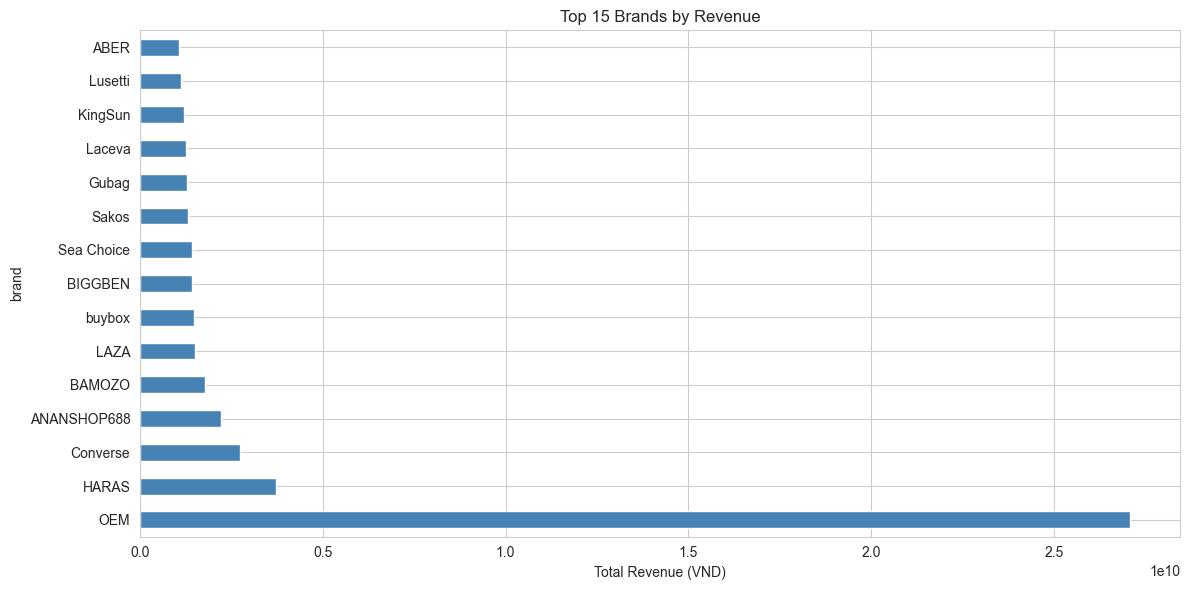

In [7]:
brand_revenue = df.groupby('brand')['revenue_estimate'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
brand_revenue.plot(kind='barh', color='steelblue')
plt.xlabel('Total Revenue (VND)')
plt.title('Top 15 Brands by Revenue')
plt.tight_layout()
plt.show()

## Rating and Review Analysis

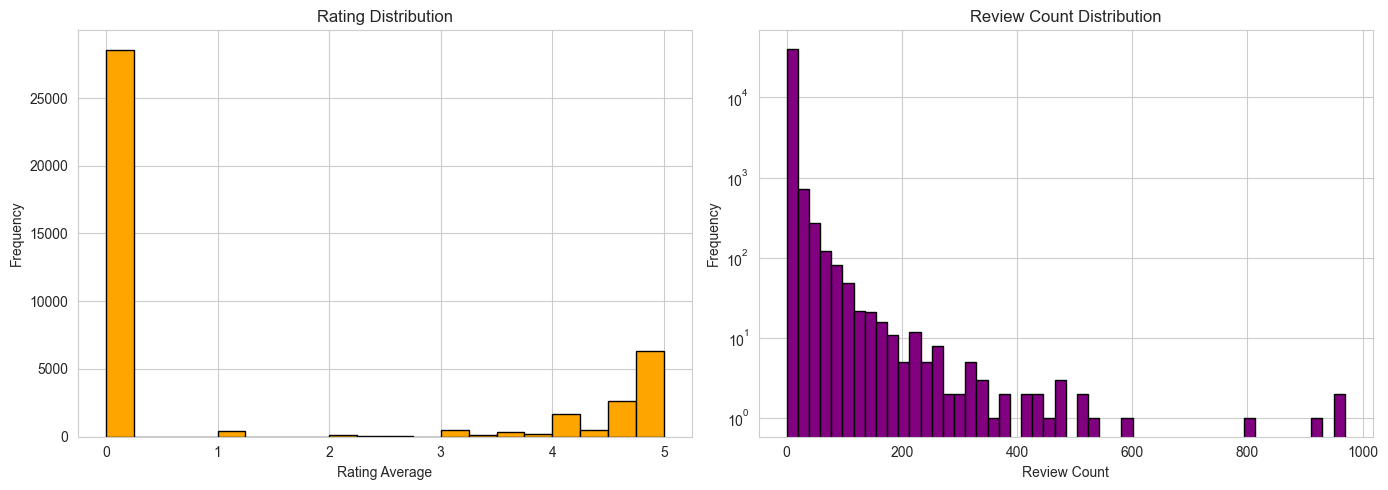

Rating statistics:
count    41576.000000
mean         1.381545
std          2.105277
min          0.000000
25%          0.000000
50%          0.000000
75%          4.000000
max          5.000000
Name: rating_average, dtype: float64

Review count statistics:
count    41576.000000
mean         3.112084
std         18.231025
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        969.000000
Name: review_count, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['rating_average'], bins=20, edgecolor='black', color='orange')
axes[0].set_xlabel('Rating Average')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Rating Distribution')

axes[1].hist(df['review_count'], bins=50, edgecolor='black', color='purple')
axes[1].set_xlabel('Review Count')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Review Count Distribution')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

print(f"Rating statistics:")
print(df['rating_average'].describe())
print(f"\nReview count statistics:")
print(df['review_count'].describe())

## Sales Performance

In [9]:
print(f"Quantity sold statistics:")
print(df['quantity_sold'].describe())

print(f"\nTop 10 best-selling products:")
top_sellers = df.nlargest(10, 'quantity_sold')[['name', 'brand', 'category', 'price', 'quantity_sold', 'rating_average']]
print(top_sellers)

Quantity sold statistics:
count    41576.000000
mean        17.776939
std        168.379391
min          0.000000
25%          0.000000
50%          0.000000
75%          5.000000
max      24847.000000
Name: quantity_sold, dtype: float64

Top 10 best-selling products:
                                                    name      brand  \
21530             Túi Đeo Chéo Unisex Laza TXTK349 (Đen)       LAZA   
40621  Miếng lót giảm size cho giày bị rộng Cao Cấp -...     buybox   
30526  Keo Dán Giày Nhiệt XIMO Trong Suốt Siêu Dính D...       Ximo   
21528   Túi Đeo Chéo Unisex Haras HRTK183VN (17 x 26 cm)      HARAS   
21409  Túi Đeo Chéo Nam HARAS HRTK105 (27 x 17 cm) - Đen      HARAS   
6312                                    Dây Thun Cột Tóc        OEM   
38369  Giày búp bê giày công sở có khả năng chịu nước...        OEM   
2657      Balo Nam Thời Trang HARAS HRTK112 (35 x 45 cm)      HARAS   
20844  Combo 5 Đôi Tất Nam Vớ Nam Cổ Dài Sợi Cotton C...  JM Jamano   
21388  Túi Đeo Chéo N

In [10]:
print(f"\nTop 10 highest revenue products:")
top_revenue = df.nlargest(10, 'revenue_estimate')[['name', 'brand', 'category', 'price', 'quantity_sold', 'revenue_estimate']]
print(top_revenue)


Top 10 highest revenue products:
                                                    name         brand  \
10010         Kính mát, mắt kính 2508 nhiều màu lựa chọn           OEM   
21530             Túi Đeo Chéo Unisex Laza TXTK349 (Đen)          LAZA   
29942  Giày Converse Chuck Taylor All Star 1970s Hi T...      Converse   
4694   Vali Kéo LUG Lusetti Nolan S20/S24/S28 LS802 N...       Lusetti   
29936  Giày Converse Chuck Taylor All Star 1970s Low ...      Converse   
4716   Vali Kamiliant Zakk Spinner TSA Thương hiệu Ch...     KAMILIANT   
4659   Vali du lịch BAMOZO 8801 vali kéo nhựa được bả...        BAMOZO   
4689   Sea Choice Bảo hành 3 năm Vali du lịch 20/24 i...    Sea Choice   
30962  Bộ Vệ Sinh Giày Dép Crep Protect Cure Kit (100ml)  Crep Protect   
40621  Miếng lót giảm size cho giày bị rộng Cao Cấp -...        buybox   

                  category    price  quantity_sold  revenue_estimate  
10010  fashion_accessories   600000           2761        1656600000  
21530    

## Correlation Analysis

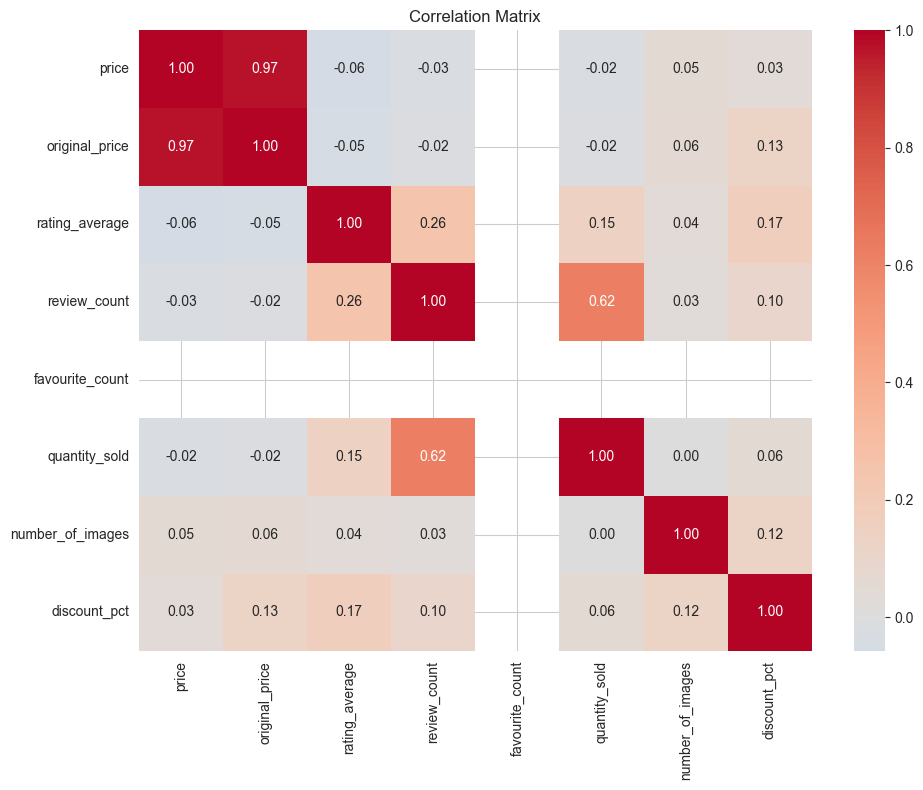

In [11]:
corr_cols = ['price', 'original_price', 'rating_average', 'review_count', 'favourite_count', 'quantity_sold', 'number_of_images', 'discount_pct']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Key Observations

In [12]:
observations = {
    'total_products': len(df),
    'total_revenue_estimate': df['revenue_estimate'].sum(),
    'avg_price': df['price'].mean(),
    'median_price': df['price'].median(),
    'avg_rating': df['rating_average'].mean(),
    'total_quantity_sold': df['quantity_sold'].sum(),
    'products_with_reviews': (df['review_count'] > 0).sum(),
    'top_category': category_stats.index[0],
    'top_brand': brand_revenue.index[0]
}

print("\n=== Key Observations ===")
for key, value in observations.items():
    print(f"{key}: {value}")


=== Key Observations ===
total_products: 41576
total_revenue_estimate: 86397708452
avg_price: 272358.878271118
median_price: 85000.0
avg_rating: 1.3815446411391188
total_quantity_sold: 739094
products_with_reviews: 13015
top_category: backpacks_suitcases
top_brand: OEM
